In [ ]:
# AND, NOT and OR gate using perceptron

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AND_df=pd.DataFrame({'x1':[0,0,1,1],'x2':[0,1,0,1],'y':[0,0,0,1]})
OR_df=pd.DataFrame({'x1':[0,0,1,1],'x2':[0,1,0,1],'y':[0,1,1,1]})
NOT_df=pd.DataFrame({'x1':[0,1],'y':[1,0]})

In [ ]:
# To plot Decision Boundary

def plot_decision_boundary(df, local_w, local_b, update_num):
    n_features = len(local_w)
    if n_features == 1:
        plt.figure(figsize=(4, 1.5))
        for index, row in df.iterrows():
            x1, target = row[0], row[-1]
            color = 'blue' if target == 1 else 'red'
            plt.scatter(x1, 0, c=color, s=100, edgecolors='k', zorder=3)

        if local_w[0] != 0:
            x_boundary = -local_b / local_w[0]
            plt.axvline(x_boundary, color='g', label='Decision boundary')
        plt.xlim(-0.5, 1.5)
        plt.yticks([])
        plt.xlabel('x1')

    elif n_features == 2:
        plt.figure(figsize=(4, 4))
        for index, row in df.iterrows():
            x1, x2, target = row[0], row[1], row[-1]
            color = 'blue' if target == 1 else 'red'
            plt.scatter(x1, x2, c=color, s=100, edgecolors='k', zorder=3)

        x_vals = np.array([-0.5, 1.5])
        if local_w[1] != 0:
            y_vals = -(local_w[0] * x_vals + local_b) / local_w[1]
            plt.plot(x_vals, y_vals, 'g-', label='Decision boundary')
        elif local_w[0] != 0:
            x_line = -local_b / local_w[0]
            plt.axvline(x_line, color='g', label='Decision boundary')
        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 1.5)
        plt.xlabel('x1')
        plt.ylabel('x2')

    else:
        print(f"Plotting only supported for 1 or 2 features (got {n_features})")
        return

    plt.title(f"Decision boundary after update {update_num}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Initial weights:  [0. 0.]
Initial bias:  0

Updated weight: [0. 0.]
Updated bias: -0.1



/tmp/ipykernel_2701/3171525465.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = row[-1]
/tmp/ipykernel_2701/165196993.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x1, x2, target = row[0], row[1], row[-1]
/tmp/ipykernel_2701/165196993.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


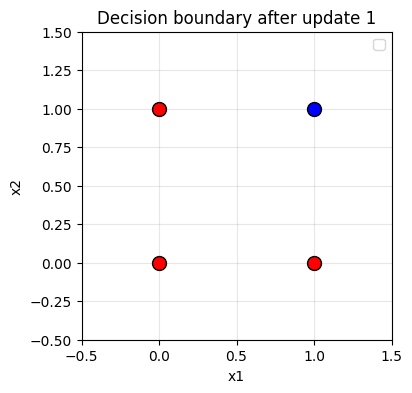

Updated weight: [0.1 0.1]
Updated bias: 0.0



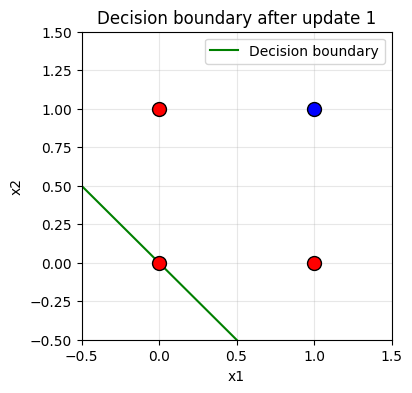

Updated weight: [0.1 0.1]
Updated bias: -0.1



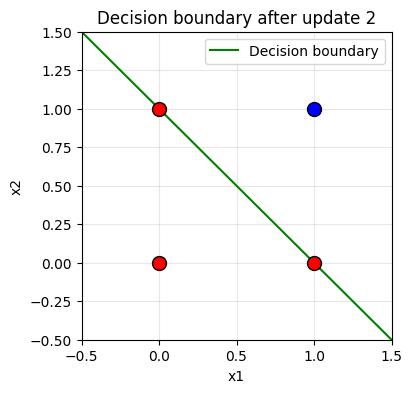

Updated weight: [0.1 0. ]
Updated bias: -0.2



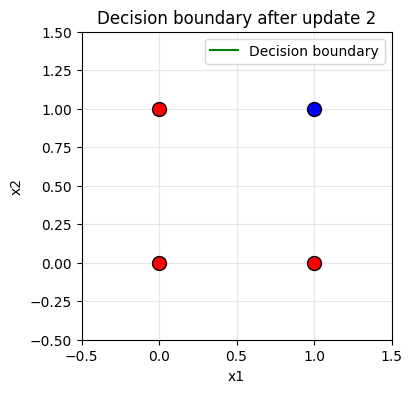

Updated weight: [0.2 0.1]
Updated bias: -0.1



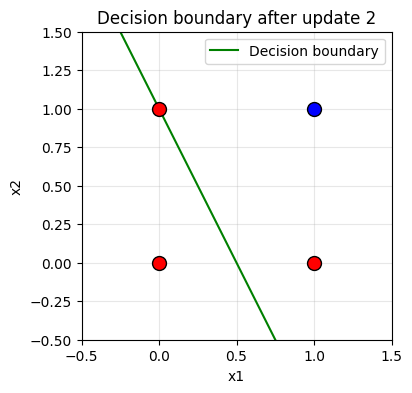

Updated weight: [0.2 0. ]
Updated bias: -0.2



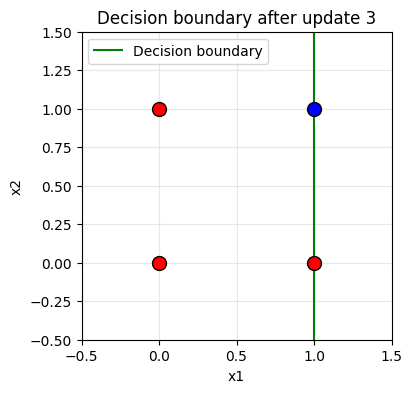

Updated weight: [0.1 0. ]
Updated bias: -0.30000000000000004



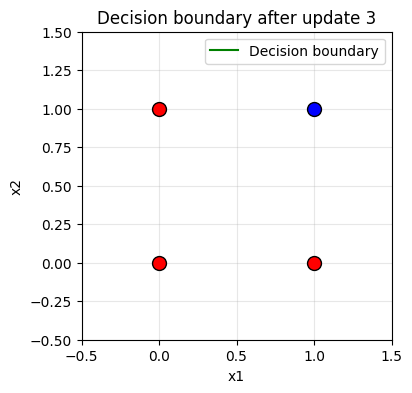

Updated weight: [0.2 0.1]
Updated bias: -0.20000000000000004



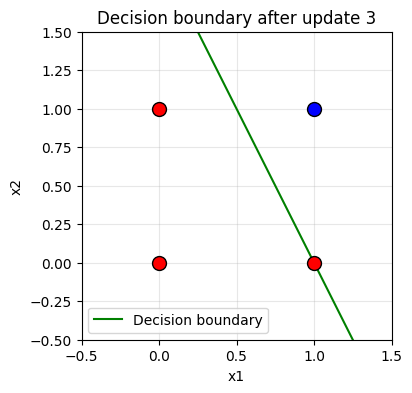

Trained weights for AND gate: [-0.2  0.2  0.1]

Testing AND gate predictions:
Enter x1: 1
Enter x2: 0
0


In [ ]:
# Training for AND gate

w=np.zeros(2)
b=0
print("Initial weights: ", w)
print("Initial bias: ", b)
print()
def AndPerceptron(df, lr, epochs):
  local_w = np.array([w[0], w[1]])
  local_b = b

  for i in range(epochs):
    for index, row in df.iterrows():
      features_for_dot = row[:-1].values
      target = row[-1]

      weighted_sum = np.dot(features_for_dot, local_w) + local_b

      if weighted_sum >= 0:
        prediction = 1
      else:
        prediction = 0

      error = target - prediction
      if error != 0:
        local_w += lr * error * features_for_dot

        local_b += lr * error

        print("Updated weight:",local_w)
        print("Updated bias:",local_b)
        print()
        plot_decision_boundary(df, local_w, local_b, i+1)


  return np.array([local_b, local_w[0], local_w[1]])

lr = 0.1
epochs = 100

trained_weights_and = AndPerceptron(AND_df, lr, epochs)

print(f"Trained weights for AND gate: {trained_weights_and}")


def predict(x1, x2, weights_array):
  features = np.array([1, x1, x2])
  weighted_sum = np.dot(features, weights_array)
  return 1 if weighted_sum >= 0 else 0

print("\nTesting AND gate predictions:")
a=int(input("Enter x1: "))
b=int(input("Enter x2: "))
print("Prediction:",predict(a, b, trained_weights_and))

Initial weights:  [0. 0.]
Initial bias:  0

Updated weight: [0. 0.]
Updated bias: -0.1



/tmp/ipykernel_2701/68407548.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = row[-1]
/tmp/ipykernel_2701/165196993.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x1, x2, target = row[0], row[1], row[-1]
/tmp/ipykernel_2701/165196993.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


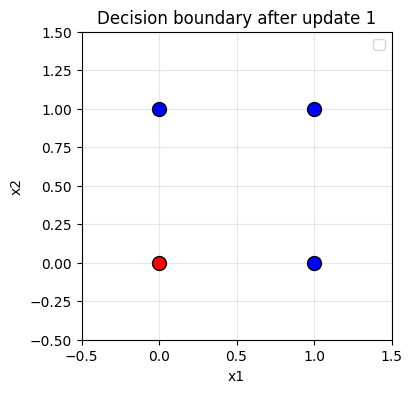

Updated weight: [0.  0.1]
Updated bias: 0.0



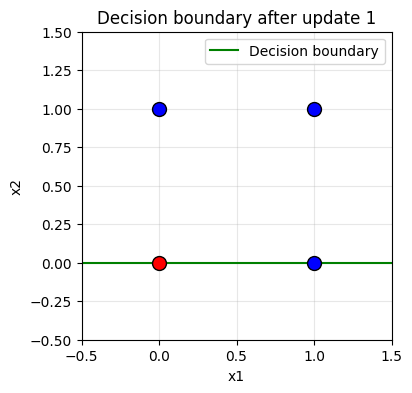

Updated weight: [0.  0.1]
Updated bias: -0.1



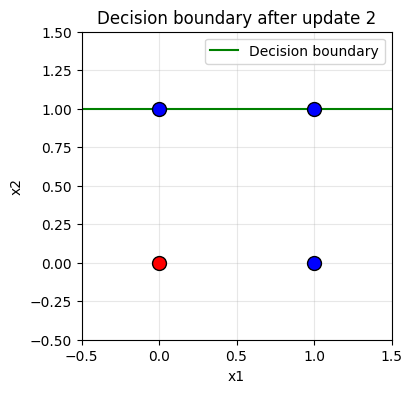

Updated weight: [0.1 0.1]
Updated bias: 0.0



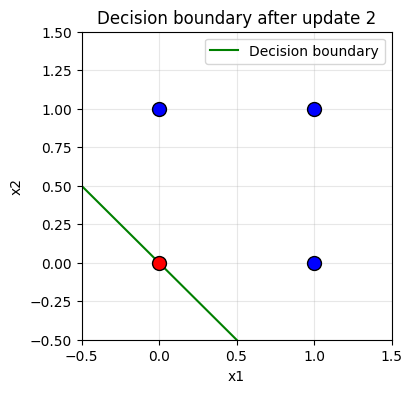

Updated weight: [0.1 0.1]
Updated bias: -0.1



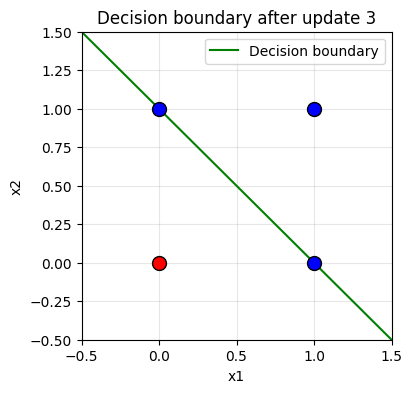

Trained weights for OR gate: [-0.1  0.1  0.1]

Testing OR gate predictions:
Enter x1: 0
Enter x2: 1
1


In [ ]:
w=np.zeros(2)
b=0

print("Initial weights: ", w)
print("Initial bias: ", b)
print()

def OrPerceptron(df, lr, epochs):
  local_w = np.array([w[0], w[1]])
  local_b = b

  for i in range(epochs):
    for index, row in df.iterrows():
      features_for_dot = row[:-1].values
      target = row[-1]

      weighted_sum = np.dot(features_for_dot, local_w) + local_b

      if weighted_sum >= 0:
        prediction = 1
      else:
        prediction = 0

      error = target - prediction
      if error != 0:
        local_w += lr * error * features_for_dot

        local_b += lr * error

        print("Updated weight:",local_w)
        print("Updated bias:",local_b)
        print()
        plot_decision_boundary(df, local_w, local_b, i+1)

  return np.array([local_b, local_w[0], local_w[1]])

lr = 0.1
epochs = 100

trained_weights_or = OrPerceptron(OR_df, lr, epochs)

print(f"Trained weights for OR gate: {trained_weights_or}")


print("\nTesting OR gate predictions:")
a=int(input("Enter x1: "))
b=int(input("Enter x2: "))

print("Prediction:",predict(a, b, trained_weights_or))

In [ ]:
w = 0
b = 0
print("Initial weights: ", w)
print("Initial bias: ", b)
print()
def NotPerceptron(df, lr, epochs):
  local_w = w
  local_b = b

  for i in range(epochs):
    for index, row in df.iterrows():
      features = row[0]
      target = row[-1]

      weighted_sum = features * local_w + local_b

      if weighted_sum >= 0:
        prediction = 1
      else:
        prediction = 0

      error = target - prediction
      if error != 0:
        local_w += lr * error * features
        local_b += lr * error

        print("Updated weight:", local_w)
        print("Updated bias:", local_b)
        print()

  return [local_b, local_w]
  return [local_b, local_w]

lr=0.1
epochs=100

def PredictNot(x1, weights_array):
  features = np.array([1, x1])
  weighted_sum = np.dot(features, weights_array)
  return 1 if weighted_sum >= 0 else 0

Not_trained_weights = NotPerceptron(NOT_df, lr, epochs)

print(f"Trained weights for NOT gate: {Not_trained_weights}")

print("\nTesting NOT gate predictions:")
a=int(input("Enter x1: "))
print("Prediction:",PredictNot(a, Not_trained_weights))

/tmp/ipykernel_2701/3099441368.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  features = row[0]
/tmp/ipykernel_2701/3099441368.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target = row[-1]


Initial weights:  0
Initial bias:  0

Updated weight: -0.1
Updated bias: -0.1

Updated weight: -0.1
Updated bias: 0.0

Trained weights for NOT gate: [np.float64(0.0), np.float64(-0.1)]

Testing NOT gate predictions:
Enter x1: 1
0
